### A MNIST-like fashion product database

In this, we classify the images into respective classes given in the dataset. We use a Neural Net and a Deep Neural Net in Keras to solve this and check the accuracy scores.

### Load tensorflow

In [0]:
import tensorflow as tf
tf.set_random_seed(42)

In [47]:
tf.__version__

'1.14.0'

### Collect Data

In [0]:
import keras
from keras.utils import np_utils
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import BatchNormalization

In [0]:
(trainX, trainY), (testX, testY) = keras.datasets.fashion_mnist.load_data()

In [50]:
x_train = trainX.reshape(60000, 784)
x_test = testX.reshape(10000, 784)
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train /= 255
x_test /= 255
print(x_train.shape[0], 'train samples')
print(x_test.shape[0], 'test samples')

(60000, 'train samples')
(10000, 'test samples')


### Convert both training and testing labels into one-hot vectors.

**Hint:** check **tf.keras.utils.to_categorical()**

In [0]:
# convert class vectors to binary class matrices
num_classes = 10
y_train = keras.utils.to_categorical(trainY, num_classes)
y_test = keras.utils.to_categorical(testY, num_classes)

### Visualize the data

Plot first 10 images in the triaining set and their labels.

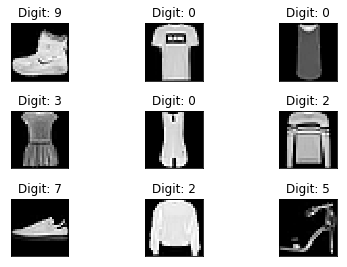

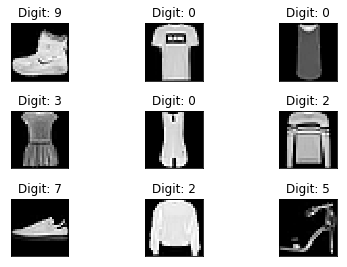

In [53]:
import matplotlib
import matplotlib.pyplot as plt

fig = plt.figure()
for i in range(9):
  plt.subplot(3,3,i+1)
  plt.tight_layout()
  plt.imshow(trainX[i], cmap='gray', interpolation='none')
  plt.title("Digit: {}".format(trainY[i]))
  plt.xticks([])
  plt.yticks([])
fig

### Build a neural Network with a cross entropy loss function and sgd optimizer in Keras. The output layer with 10 neurons as we have 10 classes.

In [57]:
model = Sequential()
model.add(Dense(512, activation='relu', input_shape=(784,)))
model.add(Dense(num_classes, activation='softmax'))

# Compile model
model.compile(loss='categorical_crossentropy', optimizer='sgd', metrics=['accuracy'])
model.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_16 (Dense)             (None, 512)               401920    
_________________________________________________________________
dense_17 (Dense)             (None, 10)                5130      
Total params: 407,050
Trainable params: 407,050
Non-trainable params: 0
_________________________________________________________________


### Execute the model using model.fit()

In [58]:
batch_size = 20
epochs = 5
history = model.fit(x_train, y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    verbose=1,
                    validation_data=(x_test, y_test))
score = model.evaluate(x_test, y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Train on 60000 samples, validate on 10000 samples
Epoch 1/5
60000/60000 [==============================] - 22s 361us/step - loss: 0.6468 - acc: 0.7872 - val_loss: 0.5089 - val_acc: 0.8266
Epoch 2/5
60000/60000 [==============================] - 22s 368us/step - loss: 0.4679 - acc: 0.8396 - val_loss: 0.4912 - val_acc: 0.8223
Epoch 3/5
60000/60000 [==============================] - 22s 366us/step - loss: 0.4275 - acc: 0.8524 - val_loss: 0.4365 - val_acc: 0.8481
Epoch 4/5
60000/60000 [==============================] - 22s 370us/step - loss: 0.4030 - acc: 0.8605 - val_loss: 0.4276 - val_acc: 0.8494
Epoch 5/5
60000/60000 [==============================] - 22s 374us/step - loss: 0.3855 - acc: 0.8659 - val_loss: 0.4311 - val_acc: 0.8480
('Test loss:', 0.4311315612077713)
('Test accuracy:', 0.848)


### In the above Neural Network model add Batch Normalization layer after the input layer and repeat the steps.

In [59]:
#Initialize Sequential Graph (model)
model = Sequential()

#Normalize input data
model.add(BatchNormalization(input_shape=(784,)))

#Add Dense layer for prediction - Keras declares weights and bias automatically
model.add(Dense(num_classes, activation='softmax'))

# Compile model
model.compile(loss='categorical_crossentropy', optimizer='sgd', metrics=['accuracy'])
model.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
batch_normalization_4 (Batch (None, 784)               3136      
_________________________________________________________________
dense_18 (Dense)             (None, 10)                7850      
Total params: 10,986
Trainable params: 9,418
Non-trainable params: 1,568
_________________________________________________________________


### Execute the model

In [60]:
history = model.fit(x_train, y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    verbose=1,
                    validation_data=(x_test, y_test))
score = model.evaluate(x_test, y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Train on 60000 samples, validate on 10000 samples
Epoch 1/5
60000/60000 [==============================] - 6s 95us/step - loss: 0.5850 - acc: 0.7975 - val_loss: 0.5026 - val_acc: 0.8263
Epoch 2/5
60000/60000 [==============================] - 5s 82us/step - loss: 0.4955 - acc: 0.8287 - val_loss: 0.4946 - val_acc: 0.8244
Epoch 3/5
60000/60000 [==============================] - 5s 84us/step - loss: 0.4796 - acc: 0.8340 - val_loss: 0.4963 - val_acc: 0.8281
Epoch 4/5
60000/60000 [==============================] - 5s 87us/step - loss: 0.4691 - acc: 0.8383 - val_loss: 0.4664 - val_acc: 0.8378
Epoch 5/5
60000/60000 [==============================] - 5s 86us/step - loss: 0.4624 - acc: 0.8382 - val_loss: 0.4715 - val_acc: 0.8354
('Test loss:', 0.4715347080230713)
('Test accuracy:', 0.8354)


### Customize the learning rate to 0.001 in sgd optimizer and run the model

In [0]:
from keras.optimizers import SGD

In [62]:
# Compile model
model.compile(loss='categorical_crossentropy', optimizer=SGD(lr=0.001), metrics=['accuracy'])
model.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
batch_normalization_4 (Batch (None, 784)               3136      
_________________________________________________________________
dense_18 (Dense)             (None, 10)                7850      
Total params: 10,986
Trainable params: 9,418
Non-trainable params: 1,568
_________________________________________________________________


In [63]:
history = model.fit(x_train, y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    verbose=1,
                    validation_data=(x_test, y_test))
score = model.evaluate(x_test, y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Train on 60000 samples, validate on 10000 samples
Epoch 1/5
60000/60000 [==============================] - 6s 106us/step - loss: 0.4417 - acc: 0.8472 - val_loss: 0.4554 - val_acc: 0.8401
Epoch 2/5
60000/60000 [==============================] - 5s 88us/step - loss: 0.4414 - acc: 0.8467 - val_loss: 0.4546 - val_acc: 0.8416
Epoch 3/5
60000/60000 [==============================] - 5s 87us/step - loss: 0.4391 - acc: 0.8483 - val_loss: 0.4553 - val_acc: 0.8425
Epoch 4/5
60000/60000 [==============================] - 5s 87us/step - loss: 0.4396 - acc: 0.8487 - val_loss: 0.4532 - val_acc: 0.8437
Epoch 5/5
60000/60000 [==============================] - 5s 87us/step - loss: 0.4378 - acc: 0.8483 - val_loss: 0.4533 - val_acc: 0.8441
('Test loss:', 0.45329382758140563)
('Test accuracy:', 0.8441)


### Build the Neural Network model with 3 Dense layers with 100,100,10 neurons respectively in each layer. Use cross entropy loss function and singmoid as activation in the hidden layers and softmax as activation function in the output layer. Use sgd optimizer with learning rate 0.03.

In [0]:
model = Sequential()
model.add(Dense(100, activation='sigmoid', input_shape=(784,)))
model.add(Dense(100, activation='sigmoid'))
model.add(Dense(num_classes, activation='softmax'))

# Compile model
model.compile(loss='categorical_crossentropy', optimizer=SGD(lr=0.03), metrics=['accuracy'])

## Review model

In [66]:
model.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_19 (Dense)             (None, 100)               78500     
_________________________________________________________________
dense_20 (Dense)             (None, 100)               10100     
_________________________________________________________________
dense_21 (Dense)             (None, 10)                1010      
Total params: 89,610
Trainable params: 89,610
Non-trainable params: 0
_________________________________________________________________


### Run the model

In [67]:
history = model.fit(x_train, y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    verbose=1,
                    validation_data=(x_test, y_test))
score = model.evaluate(x_test, y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Train on 60000 samples, validate on 10000 samples
Epoch 1/5
60000/60000 [==============================] - 7s 114us/step - loss: 0.4375 - acc: 0.8447 - val_loss: 0.4572 - val_acc: 0.8355
Epoch 2/5
60000/60000 [==============================] - 7s 117us/step - loss: 0.4212 - acc: 0.8484 - val_loss: 0.4445 - val_acc: 0.8398
Epoch 3/5
60000/60000 [==============================] - 7s 121us/step - loss: 0.4077 - acc: 0.8532 - val_loss: 0.4390 - val_acc: 0.8421
Epoch 4/5
60000/60000 [==============================] - 7s 122us/step - loss: 0.3964 - acc: 0.8567 - val_loss: 0.4264 - val_acc: 0.8456
Epoch 5/5
60000/60000 [==============================] - 7s 123us/step - loss: 0.3861 - acc: 0.8611 - val_loss: 0.4180 - val_acc: 0.8480
('Test loss:', 0.4179839261054993)
('Test accuracy:', 0.848)
